## Fitting PPV with JAX/Optax
In this example we   
- generate two PPV cubes for p-NH2D and N2D+ starting from aribrary parameters (infall+rotation)    
- optimize the model starting from another set of initial parameters    
- do some anlysis   

In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from spectra import get_lines
from model import get_ppvs, df_dparam
from optimizer import optimize
from plots import plot_channels, plot_spectra, plot_slice, plot_comparison, plot_profiles
from tqdm import tqdm

In [3]:
# change this parameters depending on your GPU capabilities
loss_target = 1e-6  # target loss for optimization stopping criterion (1e-6 is usually good)
number_of_velocity_channels = 128 # number of velocity channels in the synthetic spectra (128 is usually good)
velocity_channel_min = -2.0  # km/s
velocity_channel_max = 2.0  # km/s

### Load spectroscopic data
Load spectroscopic data from a PySpecKit model file

In [4]:
# define molecules to analyze
molecules = ["NH2D", "N2D+"]

# load line data for each molecule
vprof_neutral, Iprof_neutral, freq0_neutral = get_lines(molecules[0])
vprof_ion, Iprof_ion, freq0_ion = get_lines(molecules[1])

# define velocity channels for spectra
vchans = jnp.linspace(velocity_channel_min, velocity_channel_max, number_of_velocity_channels)


### Set the target parameters 
Define some target parameters, see comments for details.
This is an infall with rotation and an emitting gas "donut" at r=0.5.
No asymmetries, the object has some rotation on the three angles.  

In [5]:
# Where two values are given, the first is for the neutral species, the second for the ionized species
target_params = {
    'mff': 0.5,  # <<< Infall component
    'mrot': -0.5, # <<< Rotation component
    'xoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in x (plane of sky)
    'zoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in z (plane of sky)
    'vbulk': 0.1, # <<< Bulk velocity shift

    'v0': jnp.array([1e-3, 2e-3]), # <<< Velocity scaling of the Gaussian profile
    'r0_v': np.array([0.5, 0.7]), # <<< Center of the Gaussian velocity profile [0, 1]
    'sigma_v': jnp.array([0.1, 0.1]), # <<< Width of the Gaussian velocity profile

    'ngas0': jnp.array([1.0, 0.8]), # <<< Gas density scaling of the Gaussian profile
    'r0_ngas': jnp.array([0.5, 0.5]), # <<< Center of the Gaussian gas density profile [0, 1]
    'sigma_ngas': jnp.array([0.3, 0.2]), # <<< Width of the Gaussian gas density profile

    'sigma_turb': jnp.array([0.05, 0.08]), # <<< Microturbulent broadening
    'sigmadx': jnp.log10(jnp.array([0.05, 0.01])), # <<< Absorption coefficient scaling

    'theta0': jnp.pi/8., # <<< Yaw angle
    'theta1': jnp.pi*2./3., # <<< Pitch angle
    'theta2': jnp.pi/4., # <<< Roll angle
    'zratio': 0.7, # <<< Flattening of the core along the z axis

    'asym': jnp.array([0e0, 0e0]), # <<< Asymmetry scaling
    'asym_theta': jnp.array([0e0, 0e0]) # <<< Asymmetry angle
}

# bundle model arguments
model_args = {
    'Iprof': [Iprof_neutral, Iprof_ion],
    'vprof': [vprof_neutral, vprof_ion],
    'vchans': vchans
}

### Generate target model

In [6]:
ppvs_target, _, _, models_target = get_ppvs(target_params, model_args)

### Show velocity and density profiles along x, y, and z

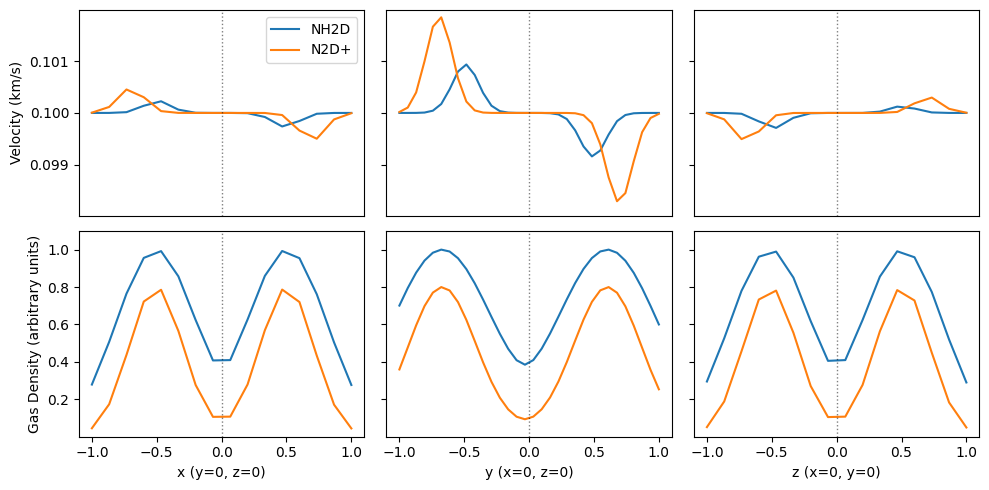

In [7]:
plot_profiles(models_target, molecules)


### Plot maps of velocity channels around maximum intensity (bracketing of PPV along V)

Velocity channel max 0.23622036 km/s


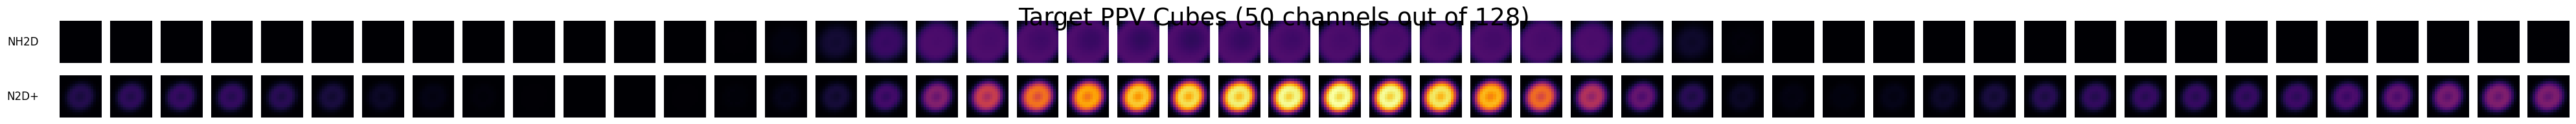

In [8]:
plot_channels(ppvs_target, vchans, molecules, nchans=50)

### Plot spectrum of the central pixel

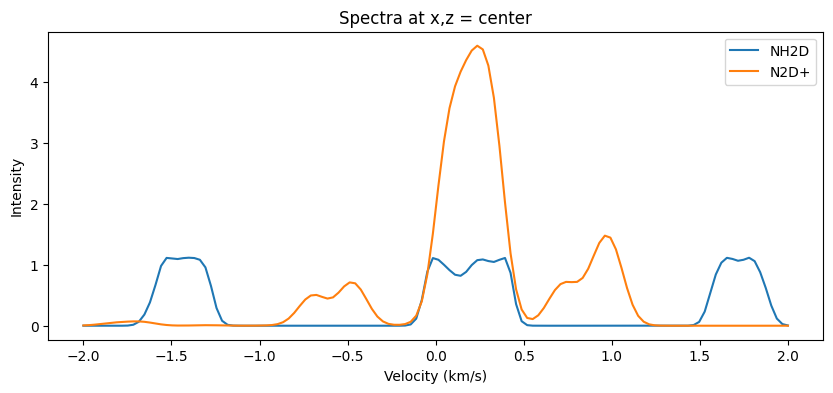

In [9]:
plot_spectra(ppvs_target, vchans, molecules)

### Velocity and density cut at z=0

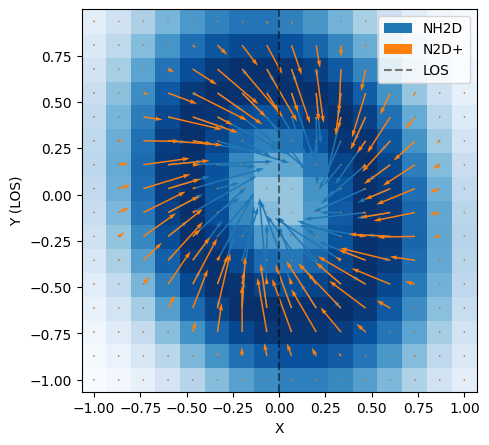

In [10]:
plot_slice(models_target, molecules)


### Set initial parameters for optimization

In [11]:
init_params  = {
    'mff': 0.1,  # <<< Infall component
    'mrot': 0.1, # <<< Rotation component
    'xoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in x (plane of sky)
    'zoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in z (plane of sky)
    'vbulk': 0e0, # <<< Bulk velocity shift

    'v0': jnp.array([1e-4, 1e-4]), # <<< Velocity scaling of the Gaussian profile
    'r0_v': np.array([0.5, 0.5]), # <<< Center of the Gaussian velocity profile [0, 1]
    'sigma_v': jnp.array([0.05, 0.05]), # <<< Width of the Gaussian velocity profile

    'ngas0': jnp.array([1e0, 1e0]), # <<< Gas density scaling of the Gaussian profile
    'r0_ngas': jnp.array([0.1, 0.1]), # <<< Center of the Gaussian gas density profile [0, 1]
    'sigma_ngas': jnp.array([0.1, 0.1]), # <<< Width of the Gaussian gas density profile

    'sigma_turb': jnp.array([0.01, 0.01]), # <<< Microturbulent broadening
    'sigmadx': jnp.log10(jnp.array([0.1, 0.01])), # <<< Absorption coefficient scaling

    'theta0': 0e0, # <<< Yaw angle
    'theta1': 0e0, # <<< Pitch angle
    'theta2': 0e0, # <<< Roll angle
    'zratio': 1e0, # <<< Flattening of the core along the z axis

    'asym': jnp.array([0e0, 0e0]), # <<< Asymmetry scaling
    'asym_theta': jnp.array([0e0, 0e0]) # <<< Asymmetry angle
}


### Plot initial guess for the central pixel spectrum

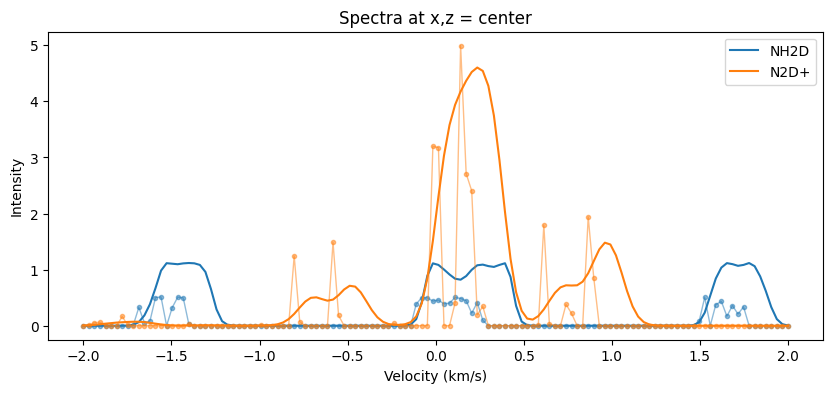

In [12]:
ppvs_init, _, _, models_init = get_ppvs(init_params, model_args)


plot_spectra(ppvs_target, vchans, molecules, ppvs_init)

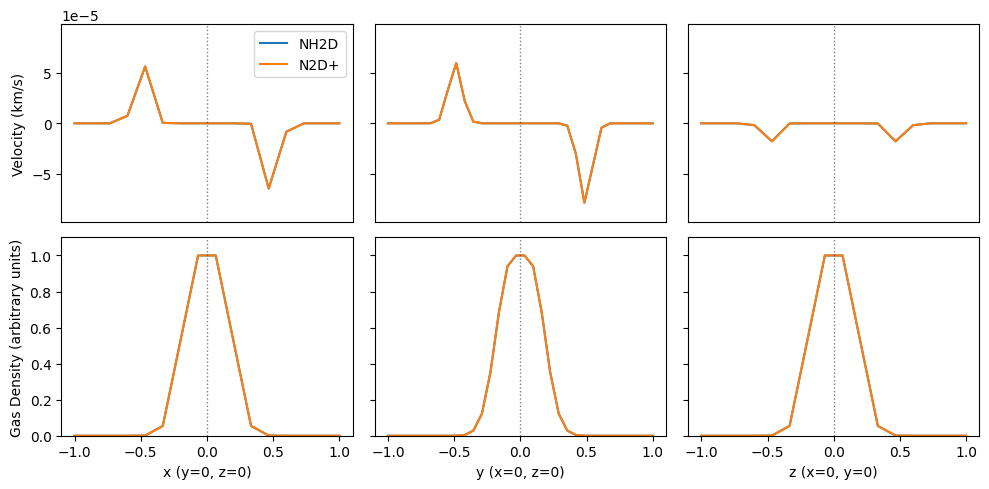

In [13]:
plot_profiles(models_init, molecules)

### Optimize

In [14]:
optimized_params = init_params
params_history = {k: [v] for k, v in init_params.items()}

optimized_params, ppvs_optimized, ems, optimized_models, params_history, loss_history = optimize(optimized_params, ppvs_target, model_args,
                                                                                         learning_rate=1e-4, epochs=int(1e5), params_history=params_history,
                                                                                         loss_target=loss_target)


Step 0/100000, Loss: 4.447663e-01 (threshold: 1.000000e-06)
Step 10/100000, Loss: 4.432419e-01 (threshold: 1.000000e-06)
Step 20/100000, Loss: 4.419548e-01 (threshold: 1.000000e-06)
Step 30/100000, Loss: 4.408178e-01 (threshold: 1.000000e-06)
Step 40/100000, Loss: 4.397515e-01 (threshold: 1.000000e-06)
Step 50/100000, Loss: 4.386972e-01 (threshold: 1.000000e-06)
Step 60/100000, Loss: 4.376111e-01 (threshold: 1.000000e-06)
Step 70/100000, Loss: 4.364561e-01 (threshold: 1.000000e-06)
Step 80/100000, Loss: 4.351992e-01 (threshold: 1.000000e-06)
Step 90/100000, Loss: 4.338168e-01 (threshold: 1.000000e-06)
Step 100/100000, Loss: 4.323058e-01 (threshold: 1.000000e-06)
Step 110/100000, Loss: 4.306868e-01 (threshold: 1.000000e-06)
Step 120/100000, Loss: 4.289927e-01 (threshold: 1.000000e-06)
Step 130/100000, Loss: 4.272497e-01 (threshold: 1.000000e-06)
Step 140/100000, Loss: 4.254687e-01 (threshold: 1.000000e-06)
Step 150/100000, Loss: 4.236466e-01 (threshold: 1.000000e-06)
Step 160/100000, Lo

### Plot Loss

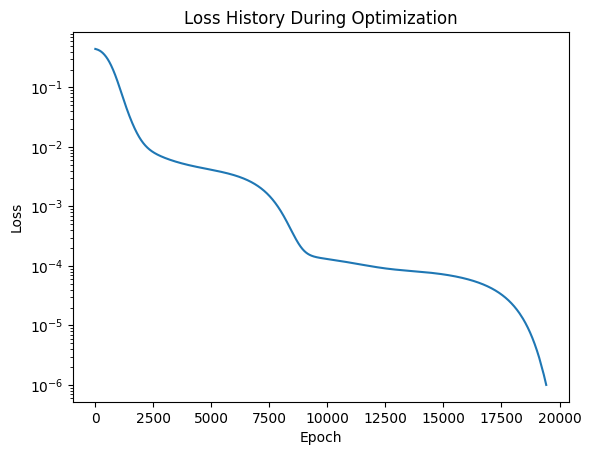

In [15]:
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History During Optimization")
plt.show()

### Plot maps of target, optimized, and their difference for both molecules (PPV bracketing along V)

Velocity channel max 0.23622036
Max difference: 0.00263797


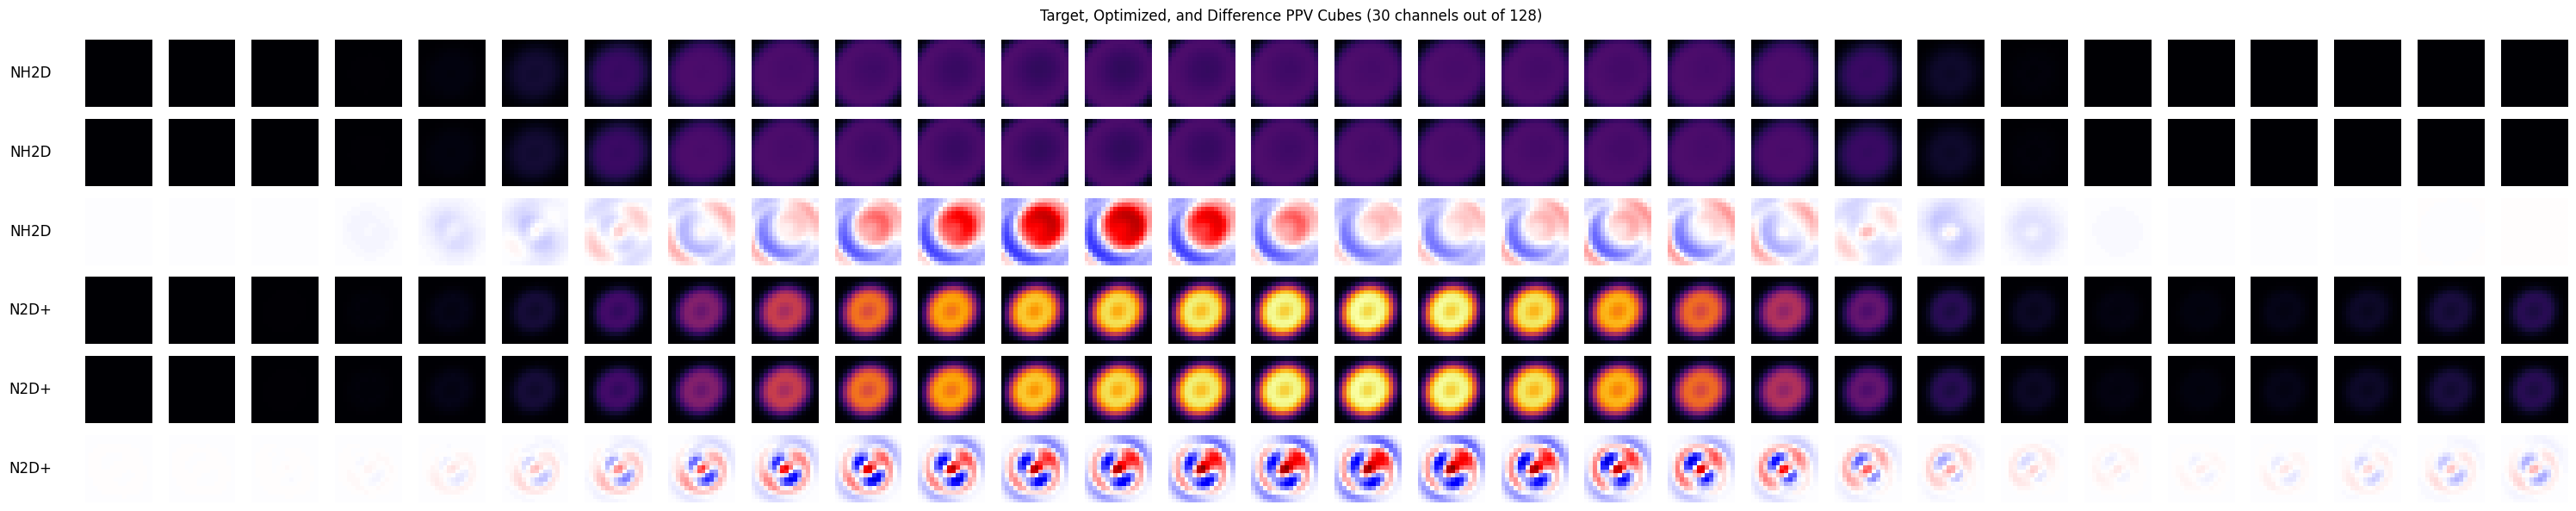

In [16]:
plot_comparison(ppvs_target, ppvs_optimized, vchans, molecules, nchans=30)


### Plot spectra in the central pixel (target vs optimized)

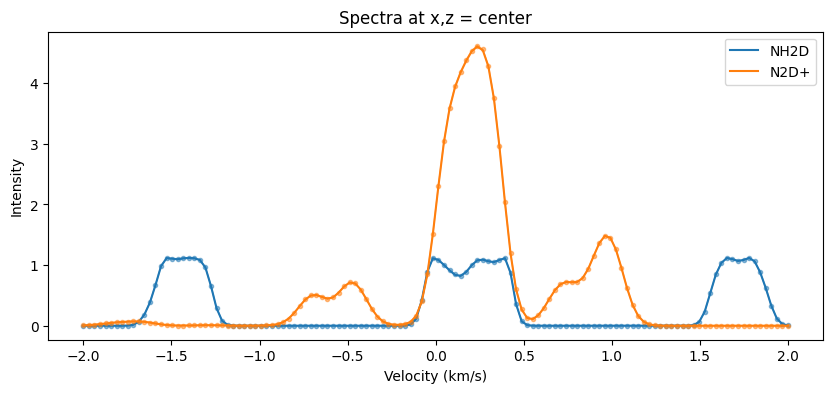

In [17]:
plot_spectra(ppvs_target, vchans, molecules, ppvs_optimized)

### Plot velocity field and density after optimization for a slice at z=0

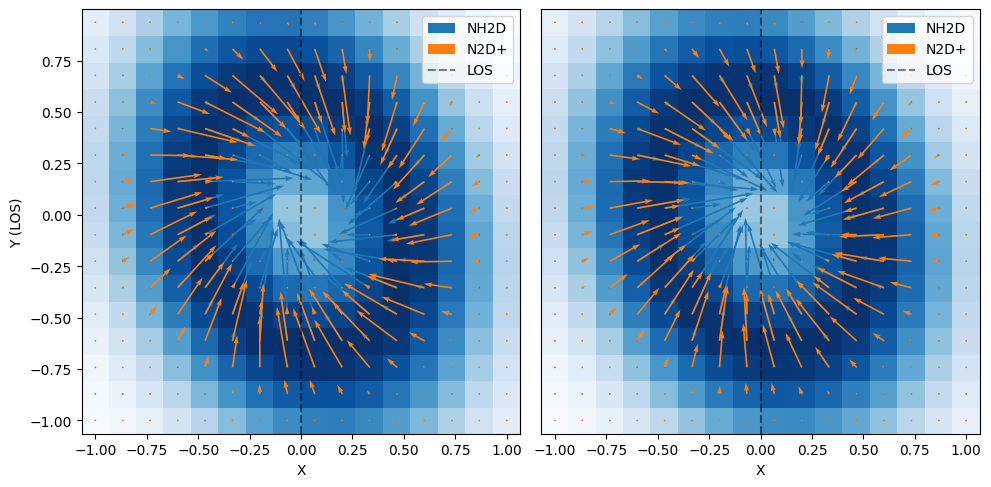

In [18]:
plot_slice([models_target, optimized_models], molecules)

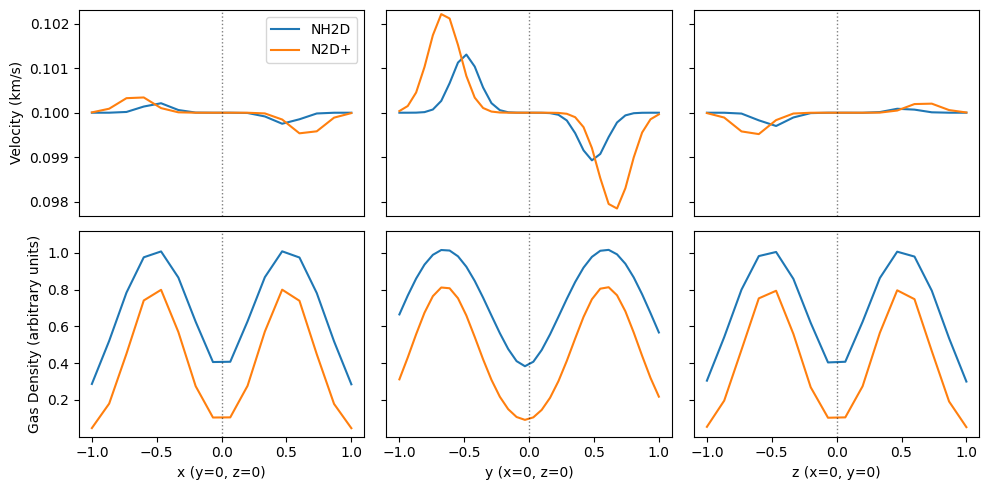

In [19]:
plot_profiles(optimized_models, molecules)

### Compute numerical derivatives of the PPV cubes with respect to each parameter

  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:24<00:00,  1.28s/it]


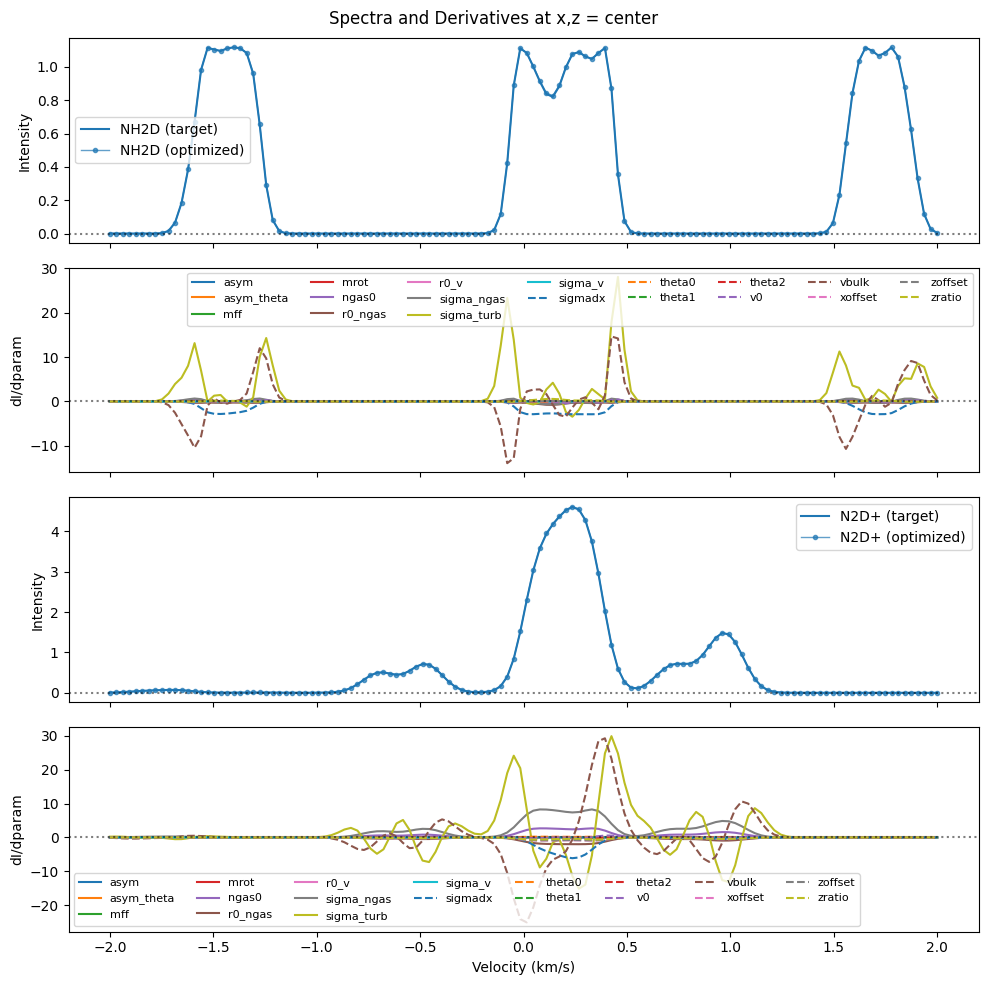

In [20]:
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
lss = ['-', '--', ':', '-.']

icount = 0
for param_name, param_value in tqdm(optimized_params.items()):
    dfdp = df_dparam(optimized_params, model_args, param_name, nmodels=2)
    #print(f"Derive wrt {param_name:16s} {np.abs(dfdp[0]).max():.6e}, {np.abs(dfdp[1]).max():.6e}")

    nmodels, nx, nz, _ = dfdp.shape
    for i in range(nmodels):
        ax = axs[i*2+1]
        ax.plot(vchans, dfdp[i, nx//2, nz//2, :], label=param_name, color=colors[icount % len(colors)], ls=lss[icount // len(colors)])

    icount += 1

for i in range(nmodels):
    ax = axs[i*2]
    p = ax.plot(vchans, ppvs_target[i, nx//2, nz//2, :], label=f"{molecules[i]} (target)")
    ax.plot(vchans, ppvs_optimized[i, nx//2, nz//2, :], label=f"{molecules[i]} (optimized)", color=p[0].get_color(), lw=1, marker='.', alpha=0.7)
    ax.legend()
    ax.set_ylabel("Intensity")

for ax in axs:
    ax.axhline(0., color='k', ls=':', alpha=0.5)

for i in [1, 3]:
    ax = axs[i]
    ax.legend(ncols=8, fontsize=8)
    ax.set_ylabel("dI/dparam")

axs[-1].set_xlabel("Velocity (km/s)")

#plt.legend()
plt.suptitle("Spectra and Derivatives at x,z = center")
plt.tight_layout()
plt.show()

### Compare final parameter values with target and initial values

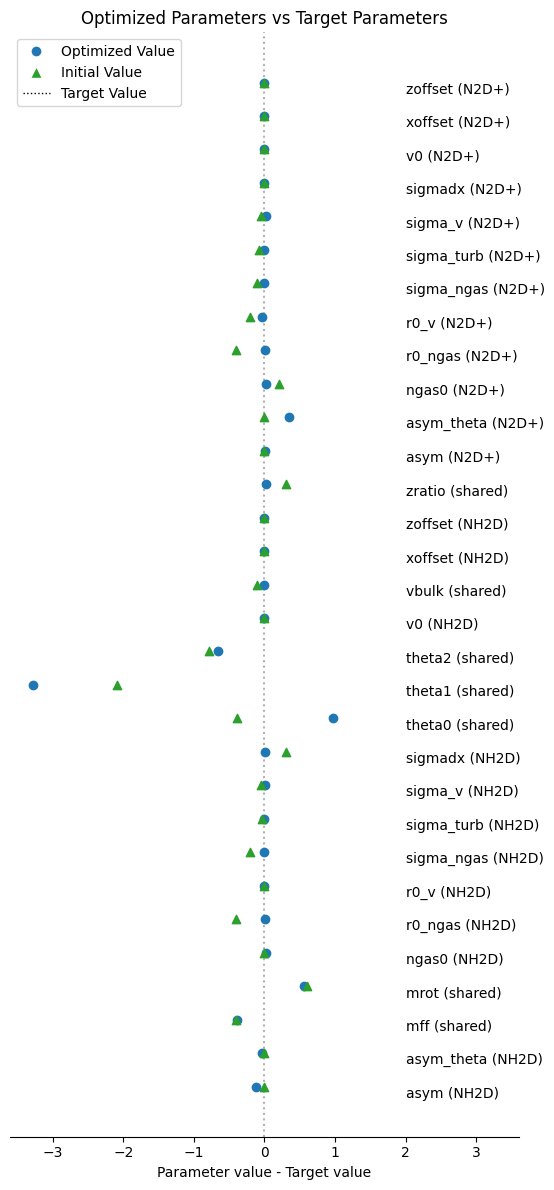

In [21]:
fig = plt.figure(figsize=(6, 12))

vmax = 0e0
icount = 0
for i in range(2):
    for k in optimized_params.keys():
        ph = params_history[k]
        ph_target = target_params[k]
        ph_init = init_params[k]
        if type(ph[0]) != float:
            v = ph[-1][i]
            v_target = ph_target[i]
            v_init = ph_init[i]
            lab = f"{k} ({molecules[i]})"
        else:
            if i >= 1:
                continue
            v = ph[-1]
            v_target = ph_target
            v_init = ph_init
            lab = f"{k} (shared)"
        plt.scatter([v - v_target], [icount], color="tab:blue")
        #plt.scatter([icount], [v_target], color="tab:orange", marker='x')
        plt.scatter([v_init - v_target], [icount], color="tab:green", marker='^')
        plt.text(2., icount, lab, rotation=0, va='top', ha='left')

        vmax = max(vmax, abs(v - v_target), abs(v_init - v_target))

        icount += 1

plt.axvline(0.0, color='k', linestyle=':', alpha=0.3, zorder=-999)
plt.yticks([])
plt.xlabel("Parameter value - Target value")
plt.tight_layout()
plt.legend([plt.Line2D([0], [0], marker='o', color='w', label='Optimized Value', markerfacecolor='tab:blue', markersize=8),
            plt.Line2D([0], [0], marker='^', color='w', label='Initial Value', markerfacecolor='tab:green', markersize=8),
            plt.Line2D([0], [0], color='k', lw=1, ls=':', label='Target Value')],
           ['Optimized Value', 'Initial Value', 'Target Value'], loc='upper left')

# remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xlim(-vmax*1.1, vmax*1.1)
plt.title("Optimized Parameters vs Target Parameters")
plt.tight_layout()
plt.show()

### Show parameter evolution during optimization

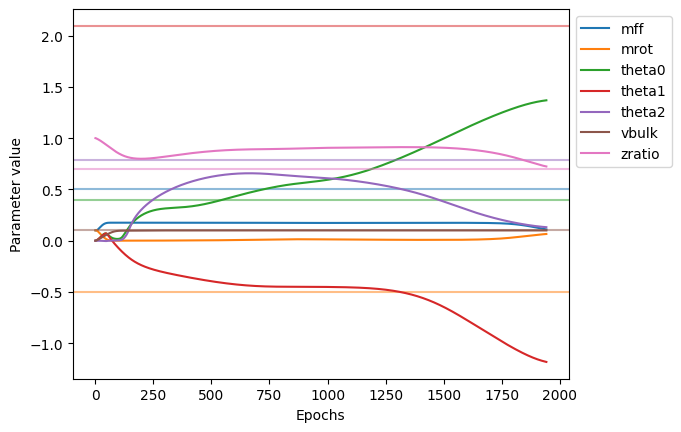

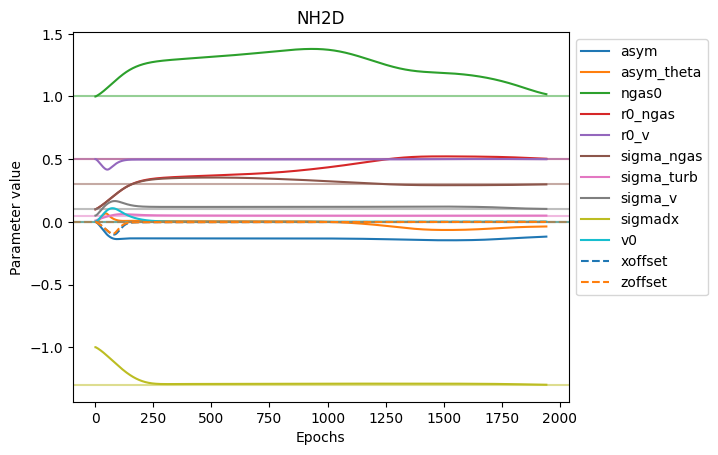

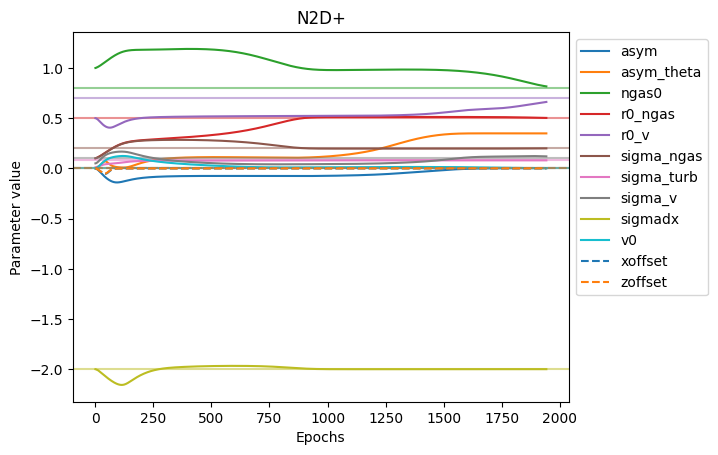

In [22]:

for k, v in optimized_params.items():
    ph = params_history[k]
    if type(ph[0]) == float:
        p = plt.plot(ph, label=k)
        plt.axhline(target_params[k], color=p[0].get_color(), alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("Parameter value")
plt.legend(ncols=1, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# get color cycle from plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
lss = ['-', '--']

for i in range(2):
    icount = 0
    for k, v in optimized_params.items():
        ph = params_history[k]
        if type(ph[0]) != float:
            plt.plot([x[i] for x in ph], label=k, color=colors[icount % len(colors)], linestyle=lss[icount // len(colors)])
            plt.axhline(target_params[k][i], color=colors[icount % len(colors)], linestyle=lss[icount // len(colors)], alpha=0.5)
            icount += 1
    plt.legend(ncols=1, loc='upper left', bbox_to_anchor=(1, 1.))
    plt.xlabel("Epochs")
    plt.ylabel("Parameter value")
    plt.title(molecules[i])
    plt.show()